# Analisis Raw Candidate Schema

Notebook ini menampilkan ringkasan dan visualisasi dataset `datasets/raw_candidate_schema.csv` yang dibangun dari `scripts/build_raw_candidate_dataset.py`.


In [1]:
from collections import Counter
from pathlib import Path
import csv
import sys

MAX_CSV_FIELD_SIZE = sys.maxsize
while True:
    try:
        csv.field_size_limit(MAX_CSV_FIELD_SIZE)
        break
    except OverflowError:
        MAX_CSV_FIELD_SIZE //= 10

import matplotlib.pyplot as plt
import polars as pl


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "config.py").exists() and (candidate / "datasets").is_dir():
            return candidate
    return current


try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()

ROOT = find_project_root(NOTEBOOK_DIR)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import config

DATASET_PATH = config.DATASETS / "raw_candidate_schema.csv"
DATASET_SOURCE = "scripts/build_raw_candidate_dataset.py"
FIGURE_DIR = config.FIGURES / "v1_shs_dataset_distribution"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(DATASET_PATH)
print(f"Source builder: {DATASET_SOURCE}")

E:\School\tugas-akhir\project\datasets\raw_candidate_schema.csv
Source builder: scripts/build_raw_candidate_dataset.py


## 1. Load Data


In [2]:
with DATASET_PATH.open(newline="", encoding="utf-8-sig") as file:
    reader = csv.DictReader(file)
    rows = [dict(row) for row in reader]
    columns = list(reader.fieldnames or [])

for row in rows:
    for column in columns:
        value = row.get(column, "")
        row[column] = value.strip() if isinstance(value, str) else value

df = pl.DataFrame(rows)

print(f"Jumlah baris: {df.height}")
print(f"Jumlah kolom: {df.width}")
if "blacklist_status" in df.columns:
    blacklist_summary_df = (
        df.group_by("blacklist_status")
        .agg(pl.len().alias("jumlah"))
        .sort("jumlah", descending=True)
    )
    non_clear_count = df.filter(pl.col("blacklist_status") != "clear").height
    print(f"Baris non-clear blacklist: {non_clear_count:,}")
else:
    blacklist_summary_df = pl.DataFrame()
    print("Kolom blacklist_status tidak tersedia; pastikan file dibangun ulang dari build_raw_candidate_dataset.py terbaru.")
print(df.columns)
if not blacklist_summary_df.is_empty():
    display(blacklist_summary_df)
with pl.Config(tbl_rows=10, tbl_cols=-1, fmt_str_lengths=120):
    display(df)


Jumlah baris: 1165
Jumlah kolom: 33
Baris non-clear blacklist: 0
['text_id', 'text', 'subjectivity_type', 'speaker_type', 'public_opinion_scope', 'corpus_role', 'aspect', 'location', 'sentiment_label', 'label_status', 'source_id', 'source_type', 'source_url', 'dataset_tier', 'inclusion_status', 'verification_status', 'evidence_support_score', 'parent_text_id', 'decision_note', 'raw_source_file', 'raw_domain', 'content_status', 'query_group', 'query', 'raw_title', 'raw_text_length', 'location_source', 'location_match', 'is_specific_location', 'blacklist_status', 'blacklist_reason_codes', 'normalized_source_url', 'blacklist_is_excluded']


blacklist_status,jumlah
str,u32
"""clear""",1165


text_id,text,subjectivity_type,speaker_type,public_opinion_scope,corpus_role,aspect,location,sentiment_label,label_status,source_id,source_type,source_url,dataset_tier,inclusion_status,verification_status,evidence_support_score,parent_text_id,decision_note,raw_source_file,raw_domain,content_status,query_group,query,raw_title,raw_text_length,location_source,location_match,is_specific_location,blacklist_status,blacklist_reason_codes,normalized_source_url,blacklist_is_excluded
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""RAW-0003""","""OIS POWER on Instagram: ""#PLTS #PanelSurya #SolarPanel #EnergiTerbarukan #SolarEnergy"" OIS POWER | #PLTS #PanelSurya #So…","""public_experience""","""public_user""","""public_opinion""","""contextual_evidence""","""general_shs""","""Sambas""","""""","""unlabeled""","""RAW-SRC-0003""","""social_media""","""https://www.instagram.com/reel/DY0bixATBPD""","""B_review_queue""","""review_required_before_core""","""perlu_verifikasi""","""0.9""","""""","""social_domain_review""","""dataset_20260627T094855Z.json""","""www.instagram.com""","""success""","""issue:benefit""","""""PLTS"" ""hemat tagihan listrik"" ""Sambas"" after:2024-01-01 before:2026-06-27""","""OIS POWER | #PLTS #PanelSurya #SolarPanel ...""","""371""","""query""","""sambas""","""true""","""clear""","""[]""","""https://instagram.com/reel/DY0bixATBPD""","""false"""
"""RAW-0004""","""TEKNIK LISTRIK on Instagram: ""Panel Surya Listrik (Fotovoltaik/PV) adalah teknologi yang mengambil energi dari cahaya ma…","""public_experience""","""public_user""","""public_opinion""","""contextual_evidence""","""general_shs""","""Sambas""","""""","""unlabeled""","""RAW-SRC-0004""","""social_media""","""https://www.instagram.com/p/DRq794LgAB2""","""B_review_queue""","""review_required_before_core""","""perlu_verifikasi""","""0.9""","""""","""social_domain_review""","""dataset_20260627T094855Z.json""","""www.instagram.com""","""success""","""issue:benefit""","""""PLTS"" ""hemat tagihan listrik"" ""Sambas"" after:2024-01-01 before:2026-06-27""","""Panel Surya Listrik (Fotovoltaik/PV) adalah teknologi yang ...""","""792""","""query""","""sambas""","""true""","""clear""","""[]""","""https://instagram.com/p/DRq794LgAB2""","""false"""
"""RAW-0005""","""Datascrip Service Center on Instagram: ""Waktu yg tepat untuk membersihkan panel surya."" Waktu yg tepat untuk membersihka…","""public_experience""","""public_user""","""public_opinion""","""contextual_evidence""","""general_shs""","""Sambas""","""""","""unlabeled""","""RAW-SRC-0005""","""social_media""","""https://www.instagram.com/reel/DQlfNxOATsq""","""B_review_queue""","""review_required_before_core""","""perlu_verifikasi""","""0.9""","""""","""social_domain_review""","""dataset_20260627T094855Z.json""","""www.instagram.com""","""success""","""issue:benefit""","""""PLTS"" ""hemat tagihan listrik"" ""Sambas"" after:2024-01-01 before:2026-06-27""","""Waktu yg tepat untuk membersihkan panel surya.""","""440""","""query""","""sambas""","""true""","""clear""","""[]""","""https://instagram.com/reel/DQlfNxOATsq""","""false"""
"""RAW-0006""","""TikTok - Make Your Day Listrik Padam Sumatera: Solusi PLTS dan Stok Cadangan ... TikTok · evanstoryy 7,2 rb+ penayangan …","""contextual_source""","""public_user""","""contextual_reference""","""excluded""","""general_shs""","""Sambas""","""""","""unlabeled""","""RAW-SRC-0006""","""social_media""","""https://www.tiktok.com/@evanstoryyy/video/7643019382251080967""","""C_holdout_excluded""","""held_out_not_for_sentiment_core""","""perlu_verifikasi""","""0.55""","""""","""content_not_success; social_domain_review""","""dataset_20260627T094855Z.json""","""www.tiktok.com""","""too_short""","""issue:benefit""","""""PLTS"" ""hemat tagihan listrik"" ""Sambas"" after:2024-01-01 before:2026-06-27""","""Listrik Padam Sumatera: Solusi PLTS dan Stok Cadangan ...""","""0""","""query""","""sambas""","""true"

## 2. Ringkasan Kolom


In [3]:
summary_rows = []
for column in columns:
    values = [row.get(column, "") for row in rows]
    filled_count = sum(1 for value in values if value)
    unique_count = len({value for value in values if value})
    summary_rows.append({
        "column": column,
        "filled_count": filled_count,
        "empty_count": len(rows) - filled_count,
        "unique_count": unique_count,
        "filled_pct": round((filled_count / len(rows)) * 100, 2) if rows else 0,
    })

summary_df = pl.DataFrame(summary_rows)
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    display(summary_df)


column,filled_count,empty_count,unique_count,filled_pct
str,i64,i64,i64,f64
"""text_id""",1165,0,1165,100.0
"""text""",1165,0,1164,100.0
"""subjectivity_type""",1165,0,5,100.0
"""speaker_type""",1165,0,4,100.0
"""public_opinion_scope""",1165,0,4,100.0
"""corpus_role""",1165,0,3,100.0
"""aspect""",1165,0,9,100.0
"""location""",1118,47,51,95.97
"""sentiment_label""",0,1165,0,0.0


## 3. Fungsi Visualisasi


In [4]:
BAR_COLOR = "#2f6f9f"
GREEN_COLOR = "#3f7d20"
ORANGE_COLOR = "#8a5a00"


def clean_value(value):
    return value if value else "(kosong)"


def value_counts(column, top=None):
    counts = Counter(clean_value(row.get(column, "")) for row in rows)
    return dict(counts.most_common(top))


def safe_filename(name):
    return "".join(char if char.isalnum() or char in "-_" else "_" for char in name).strip("_")


def finish_plot_grid(fig, filename):
    fig.tight_layout(pad=1.2)
    fig.savefig(FIGURE_DIR / filename, dpi=160, bbox_inches="tight")
    plt.show()


def make_plot_grid(plot_count, row_height=4, col_width=6):
    cols = min(2, plot_count)
    rows_count = (plot_count + cols - 1) // cols
    fig, axes = plt.subplots(rows_count, cols, figsize=(col_width * cols, row_height * rows_count))
    if plot_count == 1:
        axes = [axes]
    else:
        axes = list(axes.ravel())
    for ax in axes[plot_count:]:
        ax.axis("off")
    return fig, axes


def draw_bar(ax, column, title=None, top=None, color=BAR_COLOR):
    data = value_counts(column, top=top)
    labels = list(data.keys())
    values = list(data.values())

    ax.bar(labels, values, color=color)
    ax.set_title(title or column)
    ax.set_ylabel("Jumlah")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.25)


def draw_horizontal_bar(ax, column, title=None, top=10, color=BAR_COLOR):
    data = value_counts(column, top=top)
    labels = list(data.keys())[::-1]
    values = list(data.values())[::-1]

    ax.barh(labels, values, color=color)
    ax.set_title(title or column)
    ax.set_xlabel("Jumlah")
    ax.grid(axis="x", alpha=0.25)


def plot_bar_grid(specs, filename, row_height=4, col_width=6):
    fig, axes = make_plot_grid(len(specs), row_height=row_height, col_width=col_width)
    for ax, spec in zip(axes, specs):
        draw_bar(ax, **spec)
    finish_plot_grid(fig, filename)


def plot_horizontal_bar_grid(specs, filename, row_height=5, col_width=6):
    fig, axes = make_plot_grid(len(specs), row_height=row_height, col_width=col_width)
    for ax, spec in zip(axes, specs):
        draw_horizontal_bar(ax, **spec)
    finish_plot_grid(fig, filename)


## 4. Sebaran Scope, Role, dan Tier Dataset


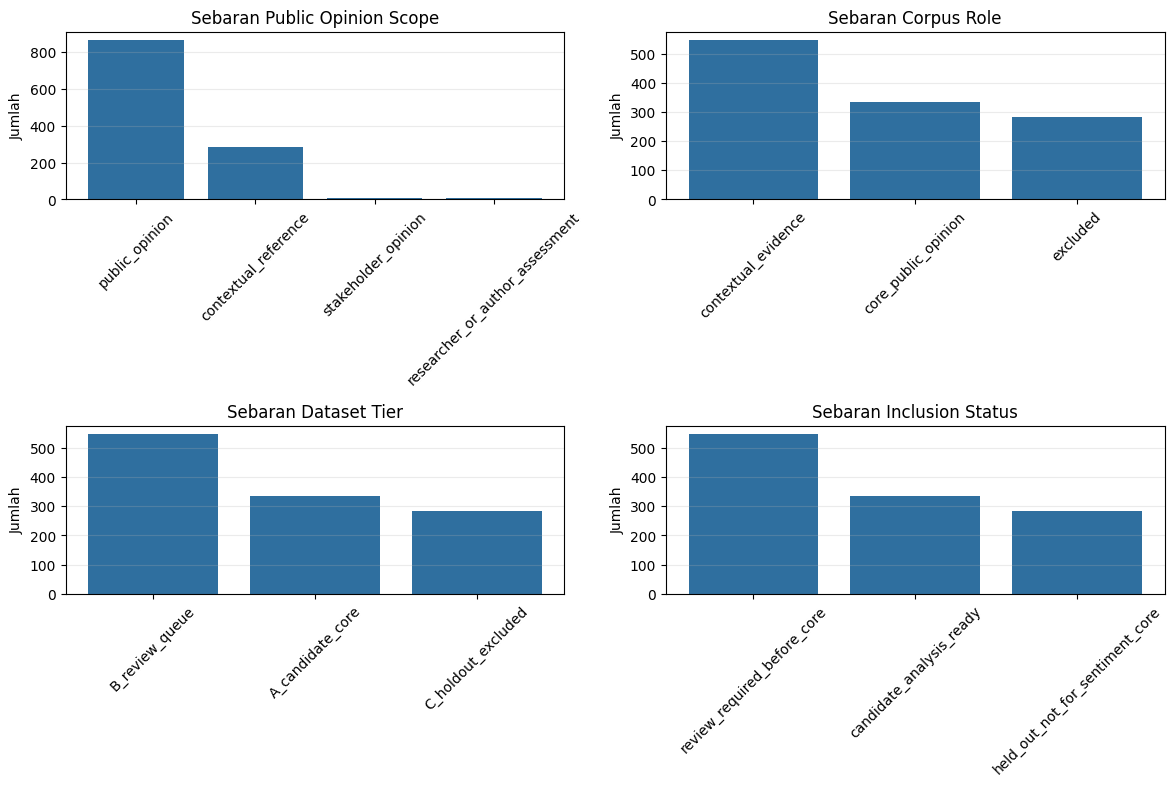

In [5]:
plot_bar_grid(
    [
        {"column": "public_opinion_scope", "title": "Sebaran Public Opinion Scope"},
        {"column": "corpus_role", "title": "Sebaran Corpus Role"},
        {"column": "dataset_tier", "title": "Sebaran Dataset Tier"},
        {"column": "inclusion_status", "title": "Sebaran Inclusion Status"},
    ],
    "scope_role_tier_inclusion.png",
    row_height=4,
    col_width=6,
)


## 5. Sebaran Status Label dan Verifikasi


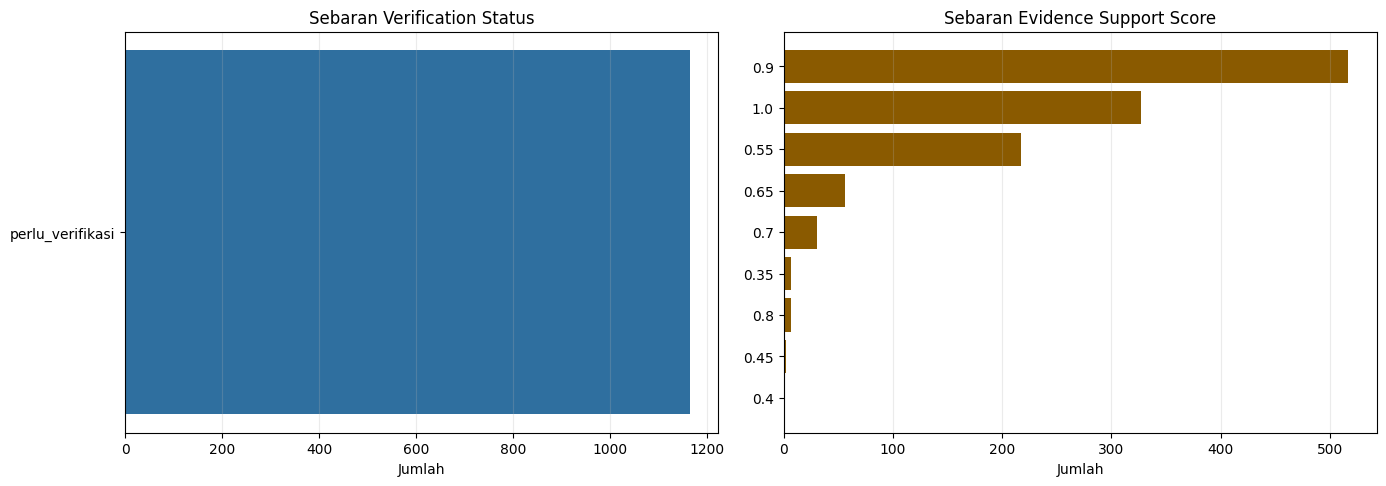

In [6]:
plot_horizontal_bar_grid(
    [
        {"column": "verification_status", "title": "Sebaran Verification Status", "top": 10},
        {"column": "evidence_support_score", "title": "Sebaran Evidence Support Score", "top": 12, "color": ORANGE_COLOR},
    ],
    "verification_and_evidence_distribution.png",
    row_height=5,
    col_width=7,
)


## 6. Sebaran Pembicara dan Subjektivitas


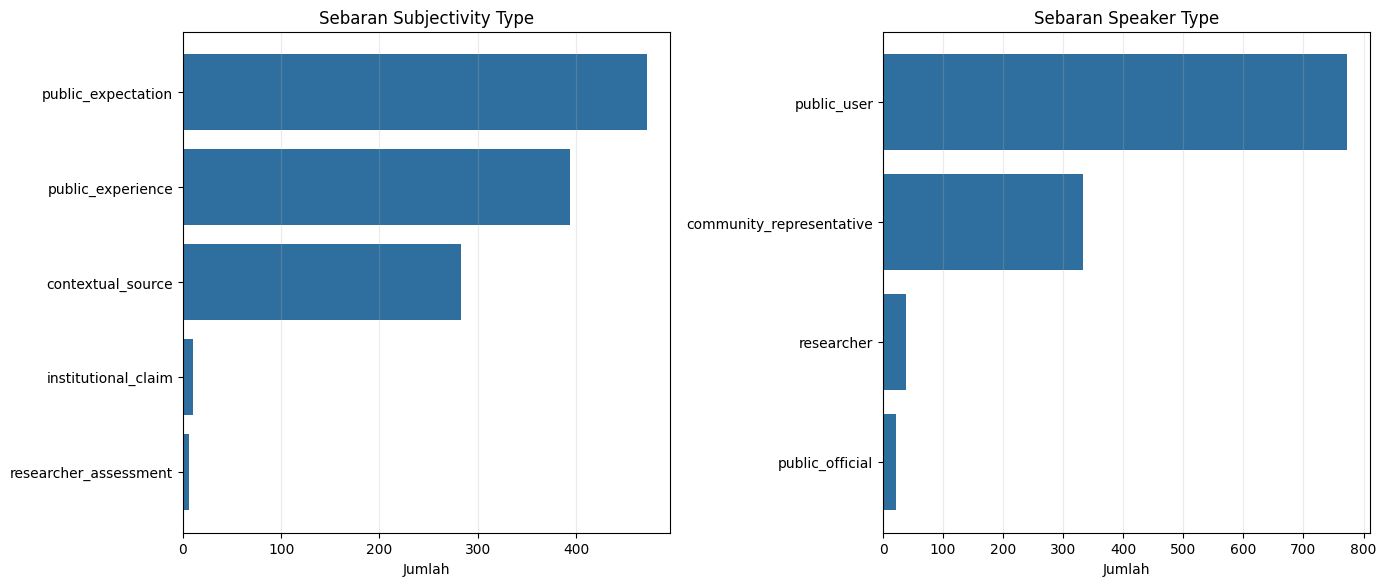

In [7]:
plot_horizontal_bar_grid(
    [
        {"column": "subjectivity_type", "title": "Sebaran Subjectivity Type", "top": 12},
        {"column": "speaker_type", "title": "Sebaran Speaker Type", "top": 15},
    ],
    "subjectivity_and_speaker_distribution.png",
    row_height=6,
    col_width=7,
)


## 7. Sebaran Sumber dan Lokasi


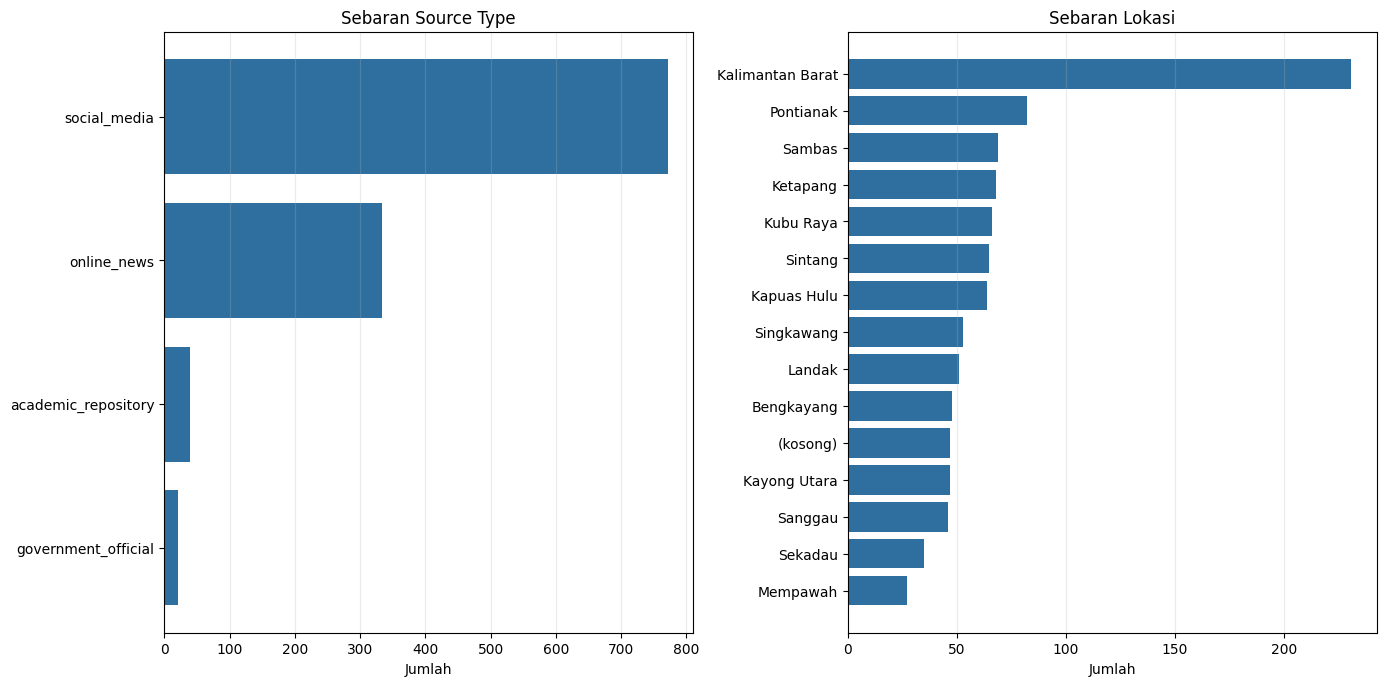

In [8]:
plot_horizontal_bar_grid(
    [
        {"column": "source_type", "title": "Sebaran Source Type", "top": 12},
        {"column": "location", "title": "Sebaran Lokasi", "top": 15},
    ],
    "source_and_location_distribution.png",
    row_height=7,
    col_width=7,
)


## 8. Sebaran Aspek


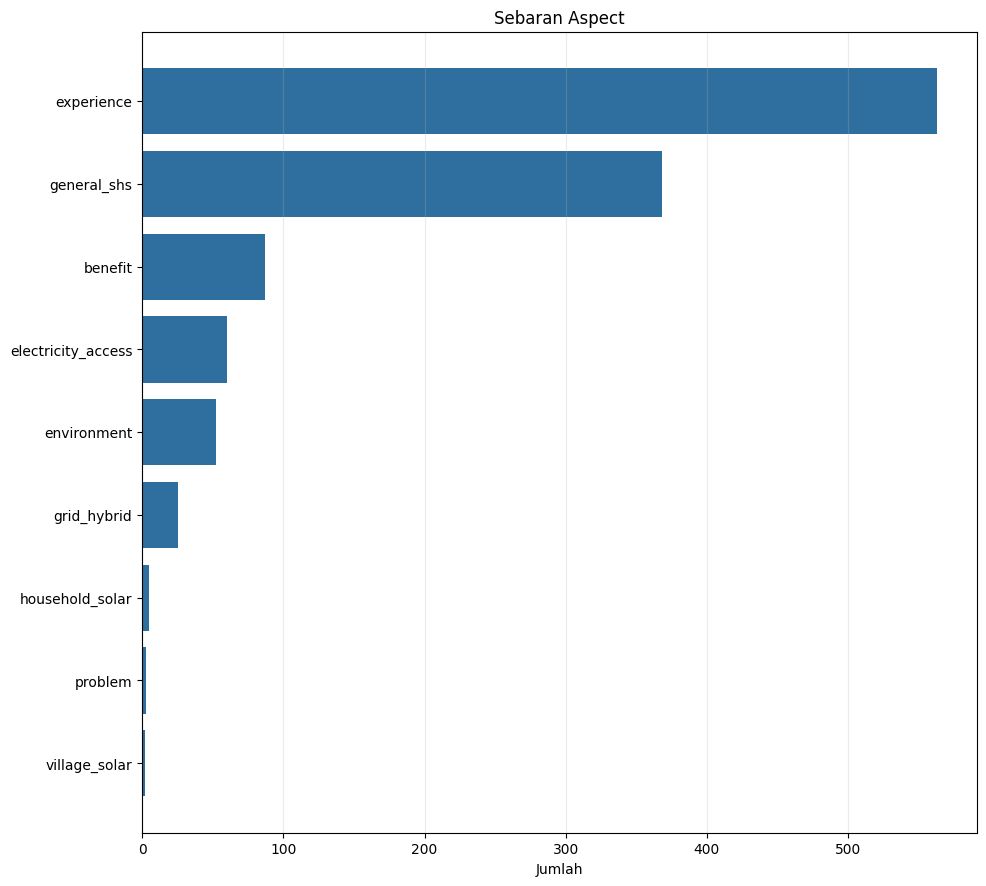

In [9]:
plot_horizontal_bar_grid(
    [
        {"column": "aspect", "title": "Sebaran Aspect", "top": 20},
    ],
    "aspect_distribution.png",
    row_height=9,
    col_width=10,
)


## 9. Contoh Teks per Tier


In [10]:
sample_columns = [
    "text_id",
    "dataset_tier",
    "inclusion_status",
    "public_opinion_scope",
    "subjectivity_type",
    "speaker_type",
    "aspect",
    "text",
]

sample_df = df.select(sample_columns).sort(["dataset_tier", "text_id"])
with pl.Config(tbl_rows=15, tbl_cols=-1, fmt_str_lengths=120):
    display(sample_df)


text_id,dataset_tier,inclusion_status,public_opinion_scope,subjectivity_type,speaker_type,aspect,text
str,str,str,str,str,str,str,str
"""RAW-0009""","""A_candidate_core""","""candidate_analysis_ready""","""public_opinion""","""public_expectation""","""community_representative""","""experience""","""Wujud Negara Hadir, Pemerintah dan PLN Berhasil Listriki 99,92 Persen Desa di Seluruh Indonesia Wujud Negara Hadir, Peme…"
"""RAW-0010""","""A_candidate_core""","""candidate_analysis_ready""","""public_opinion""","""public_expectation""","""community_representative""","""experience""","""Warga Pulau Lemukutan Harapkan Listrik 24 Jam untuk Dongkrak Pariwisata Warga Pulau Lemukutan Harapkan Listrik 24 Jam un…"
"""RAW-0016""","""A_candidate_core""","""candidate_analysis_ready""","""public_opinion""","""public_expectation""","""community_representative""","""experience""","""Bupati Ketapang Resmikan Interkoneksi Listrik Desa, Warga Pangkalan Batu Sambut Dengan Sukacita - Ketapang Media Bupati …"
"""RAW-0019""","""A_candidate_core""","""candidate_analysis_ready""","""public_opinion""","""public_expectation""","""community_representative""","""benefit""","""Menuju Ketahanan Energi: Eksplorasi Sumber Energi Terbarukan di Indonesia Eksplorasi Sumber Energi Terbarukan di Indones…"
"""RAW-0020""","""A_candidate_core""","""candidate_analysis_ready""","""public_opinion""","""public_experience""","""community_representative""","""experience""","""Peran Energi Baru Terbarukan dalam Mengatasi Perubahan Iklim Peran Energi Baru Terbarukan dalam Mengatasi ... Kumparan.c…"
"""RAW-0024""","""A_candidate_core""","""candidate_analysis_ready""","""public_opinion""","""public_expectation""","""community_representative""","""benefit""","""7 Jenis Pembangkit Listrik di Indonesia dan Sebaran Lokasi, Apa Saja? 7 Jenis Pembangkit Listrik di Indonesia dan Sebara…"
"""RAW-0046""","""A_candidate_core""","""candidate_analysis_ready""","""public_opinion""","""public_expectation""","""community_representative""","""environment""","""PLN Luncurkan Proyek PLTS Mentari Nusantara Berbasis GIGA ONE - RRI.co.id PLN Luncurkan Proyek PLTS Mentari Nusantara Be…"
"""RAW-0047""","""A_candidate_core""","""candidate_analysis_ready""","""public_opinion""","""public_expectation""","""community_representative""","""experience""","""PLTS Terbengkalai, Kanopi Soroti Makna Transisi Energi Bersih - RRI.co.id PLTS Terbengkalai, Kanopi Soroti Makna Transis…"
…,…,…,…,…,…,…,…
